In [378]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [379]:
iris = sns.load_dataset('iris')
print(iris.head())
print(iris.tail())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
     sepal_length  sepal_width  petal_length  petal_width    species
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica


In [380]:
data = torch.tensor(iris[iris.columns[0:4]].values).float()
labels = torch.zeros(len(data), dtype=torch.long)
labels[iris.species == 'setosa'] = 0
labels[iris.species == 'versicolor'] = 1
labels[iris.species == 'virginica'] = 2

In [381]:
# Experiment 1: define models using a python class + hold-out validation implementation
class NNModel(nn.Module):
    def __init__(self, n_units, n_layers):
        super().__init__()

        self.layers = nn.ModuleDict()
        self.n_layers = n_layers

        self.layers['input'] = nn.Linear(4, n_units)

        for i in range(n_layers):
            self.layers[f'hidden{i}'] = nn.Linear(n_units, n_units)

        self.layers['output'] = nn.Linear(n_units, 3)

    def forward(self, x):
        x = self.layers['input'](x)
        x = F.relu(x)

        for i in range(self.n_layers):
            x = self.layers[f'hidden{i}'](x)
            x = F.relu(x)

        x = self.layers['output'](x)
        return x

    def fit(self, data, labels, training_epochs, train_set_size):
        loss_func = nn.CrossEntropyLoss()
        optimizer = torch.optim.SGD(self.parameters(), lr=0.02)
        train_data, test_data, train_labels, test_labels = train_test_split(data, labels, train_size=train_set_size)
        test_accuracy = torch.zeros(training_epochs)
        train_accuracy = torch.zeros(training_epochs)

        for epoch in range(training_epochs):
            y_hat = self.forward(train_data)

            loss = loss_func(y_hat, train_labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_preds = torch.argmax(self.forward(train_data), dim=1)
            train_accuracy[epoch] = 100 * torch.mean((train_preds == train_labels).float())

            test_preds = torch.argmax(self.forward(test_data), dim=1)
            test_accuracy[epoch] = 100 * torch.mean((test_preds == test_labels).float())

        return train_accuracy, test_accuracy


/Users/rowobin/Documents/GitHub/ai-ml-diary/.venv/lib/python3.14/site-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


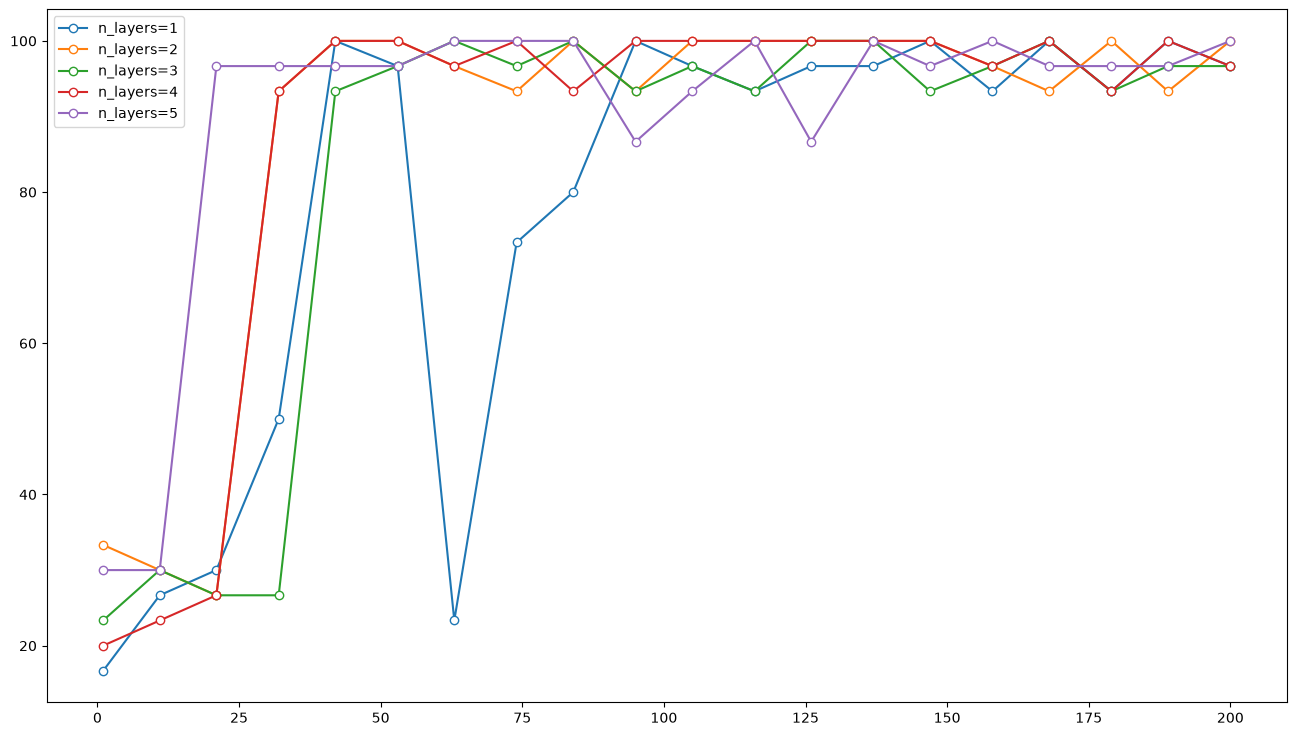

In [382]:
n_layers = torch.linspace(1, 5, 5).int()
n_hidden = torch.linspace(1, 200, int(200/10)).int()
accuracies = torch.zeros([len(n_layers), len(n_hidden)])

for layer in range(len(n_layers)):
    for hidden in range(len(n_hidden)):
        model = NNModel(hidden, layer)
        train_accuracy, test_accuracy = model.fit(data, labels, 2500, 0.8)
        accuracies[layer, hidden] = test_accuracy[-1]

plt.figure(figsize=(16, 9))
for layer in range(len(n_layers)):
    plt.plot(n_hidden, accuracies[layer-1], 'o-', label=f"n_layers={layer+1}", markerfacecolor='w')
plt.legend()
plt.show()

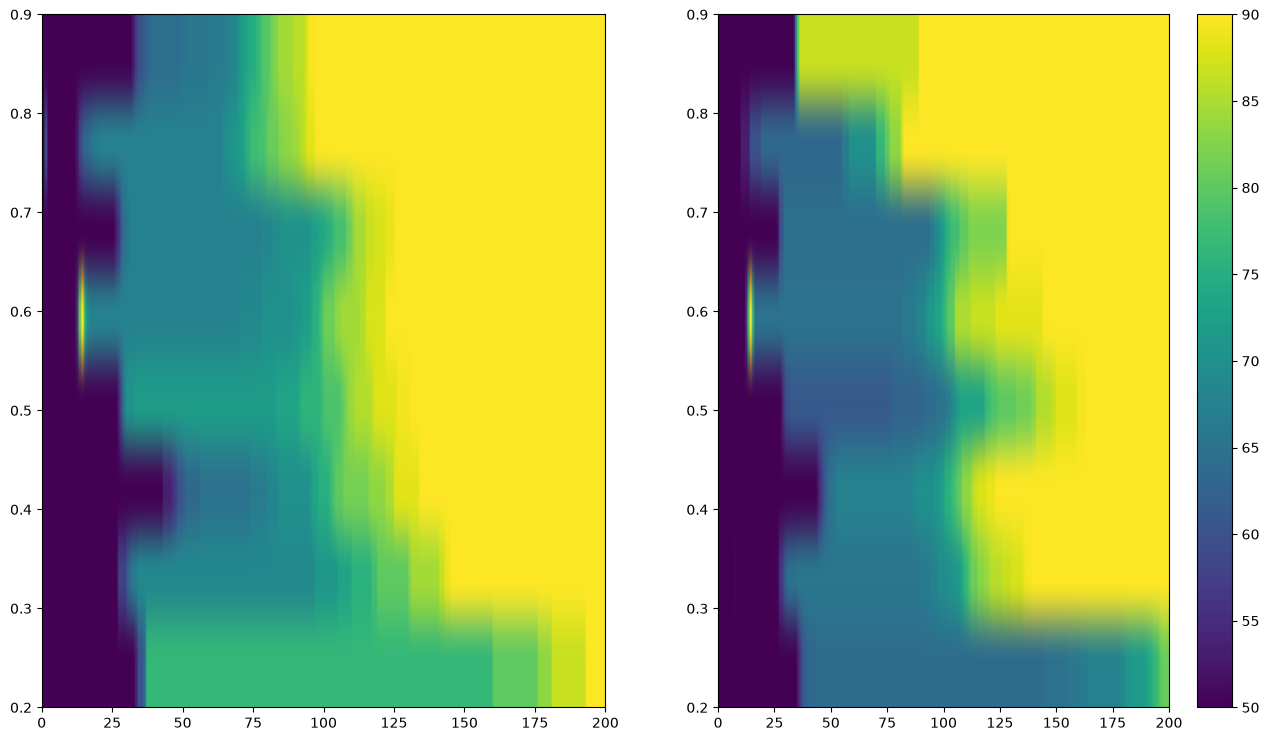

In [383]:
# Experiment 2: Analyzing the effect of training set size on model performance
training_set_sizes = np.linspace(0.2, 0.9, 8)
training_epochs = 200
train_accuracies = torch.zeros((len(training_set_sizes), training_epochs))
test_accuracies = torch.zeros((len(training_set_sizes), training_epochs))

for i in range(len(training_set_sizes)):
    model = NNModel(64, 2)
    train_accuracies[i], test_accuracies[i] = model.fit(data, labels, training_epochs, training_set_sizes[i])

fig, ax = plt.subplots(1, 2, figsize=(16, 9))
ax[0].imshow(train_accuracies, aspect="auto", origin="lower", extent=[0, training_epochs, training_set_sizes[0], training_set_sizes[-1]], vmin=50, vmax=90)
p = ax[1].imshow(test_accuracies, aspect="auto", origin="lower", extent=[0, training_epochs, training_set_sizes[0], training_set_sizes[-1]], vmin=50, vmax=90)
fig.colorbar(p, ax=ax[1])
plt.show()

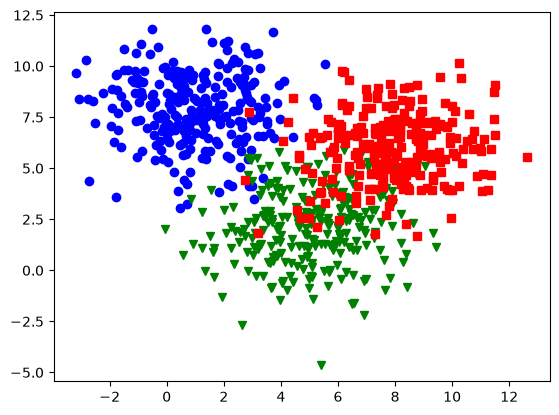

In [395]:
# Experiment 3: batch training + cross validation
N = 256

a = [1, 8]
b = [5, 2]
c = [8, 6]
blur = 1.75

A = [a[0] + np.random.randn(N) * blur, a[1] + np.random.randn(N) * blur]
B = [b[0] + np.random.randn(N) * blur, b[1] + np.random.randn(N) * blur]
C = [c[0] + np.random.randn(N) * blur, c[1] + np.random.randn(N) * blur]
data = torch.tensor(np.hstack((A, B, C)).T).float()
labels = torch.tensor(np.hstack((np.zeros(N), np.ones(N), np.ones(N) * 2)), dtype=torch.long)

plt.plot(data[np.where(labels == 0)[0], 0], data[np.where(labels == 0)[0], 1], 'bo')
plt.plot(data[np.where(labels == 1)[0], 0], data[np.where(labels == 1)[0], 1], 'gv')
plt.plot(data[np.where(labels == 2)[0], 0], data[np.where(labels == 2)[0], 1], 'rs')
plt.show()

In [396]:
class LinearModelReg(nn.Module):
    def __init__(self, n_units, n_layers):
        super().__init__()

        self.layers = nn.ModuleDict()
        self.n_layers = n_layers

        self.layers['input'] = nn.Linear(2, n_units)
        for i in range(n_layers):
            self.layers[f'hidden{i}'] = nn.Linear(n_units, n_units)
        self.layers['output'] = nn.Linear(n_units, 3)

    def forward(self, x):
        x = self.layers['input'](x)
        x = F.relu(x)

        for i in range(self.n_layers):
            x = self.layers[f'hidden{i}'](x)
            x = F.relu(x)

        x = self.layers['output'](x)

        return x

    def fit(self, data, labels, training_epochs, train_size):
        loss_func = nn.CrossEntropyLoss()
        optimizer = torch.optim.SGD(self.parameters(), lr=0.02)
        train_data, test_data, train_labels, test_labels = train_test_split(data, labels, train_size=train_size)

        train_losses = np.zeros(training_epochs)
        train_accuracies = np.zeros(training_epochs)
        test_accuracies = np.zeros(training_epochs)

        for epoch in range(training_epochs):
            y_hat = self.forward(train_data)
            
            loss = loss_func(y_hat, train_labels)
            train_losses[epoch] = loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_accuracies[epoch] = torch.mean((torch.argmax(y_hat, dim=1) == train_labels).float())
            test_accuracies[epoch] = torch.mean((torch.argmax(self.forward(test_data), dim=1) == test_labels).float())

        return train_losses, train_accuracies, test_accuracies



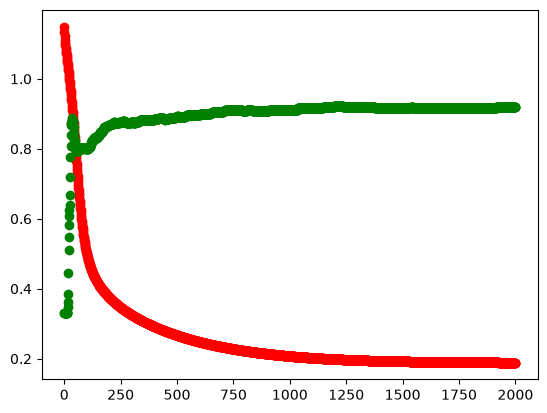

In [397]:
reg_model = LinearModelReg(8, 2)
train_losses, train_accuracies, test_accuracies = reg_model.fit(data, labels, 2000, 0.8)

plt.plot(train_losses, 'ro')
plt.plot(train_accuracies, 'go')
plt.show()

In [398]:
class LinearModelBatch(nn.Module):
    def __init__(self, n_units, n_layers):
        super().__init__()

        self.layers = nn.ModuleDict()
        self.n_layers = n_layers

        self.layers['input'] = nn.Linear(2, n_units)
        for i in range(n_layers):
            self.layers[f'hidden{i}'] = nn.Linear(n_units, n_units)
        self.layers['output'] = nn.Linear(n_units, 3)

    def forward(self, x):
        x = self.layers['input'](x)
        x = F.relu(x)

        for i in range(self.n_layers):
            x = self.layers[f'hidden{i}'](x)
            x = F.relu(x)

        x = self.layers['output'](x)

        return x

    def fit(self, data, labels, training_epochs, train_size, batch_size):
        loss_func = nn.CrossEntropyLoss()
        optimizer = torch.optim.SGD(self.parameters(), lr=0.02)
        train_data, test_data, train_labels, test_labels = train_test_split(data, labels, train_size=train_size)

        train_losses = np.zeros(training_epochs)
        train_accuracies = np.zeros(training_epochs)
        test_accuracies = np.zeros(training_epochs)

        train_ldr = DataLoader(TensorDataset(torch.tensor(train_data), torch.tensor(train_labels)), batch_size)
        print(train_ldr)

        for epoch in range(training_epochs):
            batch_losses = torch.zeros(len(train_ldr))
            for i, batch in enumerate(train_ldr):
                y_hat = self.forward(batch[0])

                loss = loss_func(y_hat, batch[1])
                batch_losses[i] = loss

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            train_losses[epoch] = torch.mean(batch_losses)
            train_accuracies[epoch] = torch.mean((torch.argmax(self.forward(train_data), dim=1) == train_labels).float())
            test_accuracies[epoch] = torch.mean((torch.argmax(self.forward(test_data), dim=1) == test_labels).float())

        return train_losses, train_accuracies, test_accuracies



/var/folders/y7/t_kyj9cd5md46_6j9s4r2sl80000gp/T/ipykernel_32283/3901711669.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ldr = DataLoader(TensorDataset(torch.tensor(train_data), torch.tensor(train_labels)), batch_size)


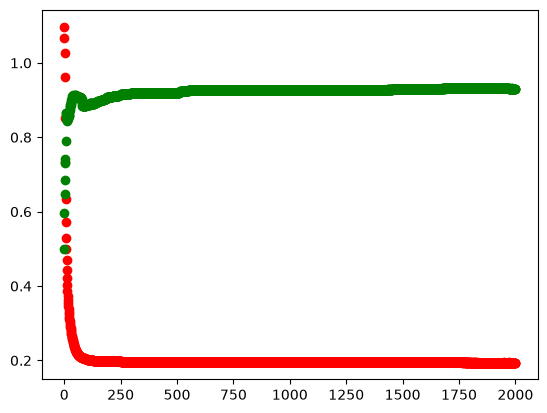

In [399]:
reg_model = LinearModelBatch(8, 2)
train_losses, train_accuracies, test_accuracies = reg_model.fit(data, labels, 2000, 0.8, 32)

plt.plot(train_losses, 'ro')
plt.plot(train_accuracies, 'go')
plt.show()